<a href="https://colab.research.google.com/github/pattichis/MLSP2026/blob/main/Video_Transformers_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Transformers for Video: A Fast Tutorial

This notebook takes about 10 minutes. It uses pretrained models from Hugging Face; no training is needed.

**How a video transformer works**

1. **Sample frames.** Take, for example, 16 frames spread across the clip.
2. **Cut into tubelets.** A tubelet is a small 3D block of pixels: 2 frames × 16 × 16 pixels. It is the video version of a Vision Transformer (ViT) image patch.
3. **Embed.** Each tubelet becomes one token (a vector), plus a position embedding that says *where* and *when* it came from.
4. **Attend.** Transformer layers let every token attend to every other token, across **space and time**. This is how the model relates a hand in frame 1 to a fork in frame 12.
5. **Predict.** Pool the tokens and classify, or compare them with text.

| Section | Model | Task |
|---|---|---|
| 2 | **VideoMAE** (Kinetics-400) | Action recognition: 400 human actions |
| 3 | VideoMAE | Look inside: tokens and attention |
| 4 | VideoMAE | Does the model use time? Shuffle the frames |
| 5 | **X-CLIP** | Zero-shot: match a video to any text you write |

Use a fresh runtime. A GPU (**Runtime → Change runtime type → GPU**) is faster, but CPU works.

## 1. Setup: load a video and sample frames

Device: cuda   Frames: 16   Frame size: (360, 640, 3)


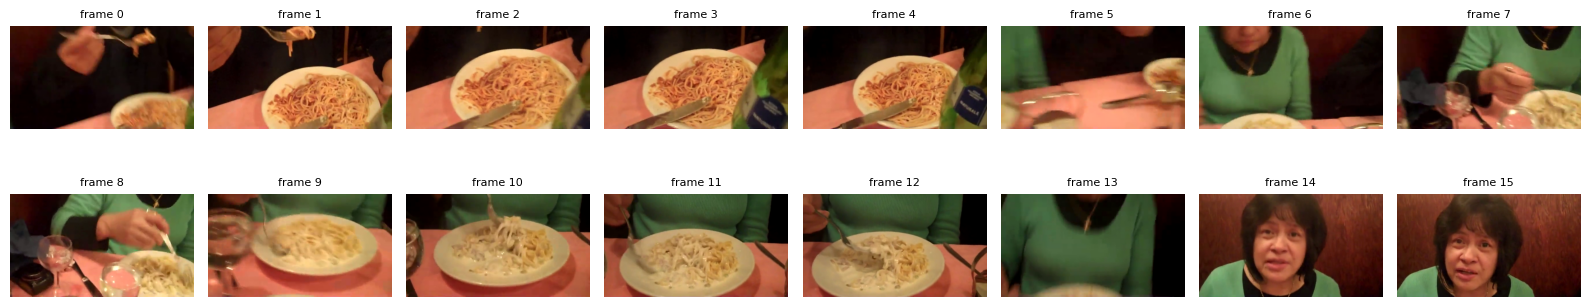

In [ ]:
!pip install -q av

import av, torch, numpy as np, matplotlib.pyplot as plt
from huggingface_hub import hf_hub_download

device = "cuda" if torch.cuda.is_available() else "cpu"

# A 10-second demo clip from Hugging Face (someone eating spaghetti)
path = hf_hub_download(repo_id="nielsr/video-demo", filename="eating_spaghetti.mp4", repo_type="dataset")

def load_frames(path, num_frames):
    """Decode a video and return num_frames RGB frames spread evenly across it."""
    with av.open(path) as container:
        frames = [f.to_ndarray(format="rgb24") for f in container.decode(video=0)]
    idx = np.linspace(0, len(frames) - 1, num_frames).astype(int)
    return [frames[i] for i in idx]

video = load_frames(path, 16)
print(f"Device: {device}   Frames: {len(video)}   Frame size: {video[0].shape}")

fig, ax = plt.subplots(2, 8, figsize=(16, 4))
for i, a in enumerate(ax.flat):
    a.imshow(video[i]); a.set_title(f"frame {i}", fontsize=8); a.axis("off")
plt.tight_layout(); plt.show()

## 2. Action recognition with VideoMAE

VideoMAE is a ViT for video. It was pretrained by hiding 90% of the tubelets and learning to reconstruct them (a masked autoencoder), and then fine-tuned on **Kinetics-400**, a dataset of 400 human actions.

In [ ]:
from transformers import AutoImageProcessor, VideoMAEForVideoClassification
from transformers.utils import logging
from safetensors.torch import load_file
logging.set_verbosity_error()      # hide the load report; the bias issue it flags is fixed below

def restore_videomae_biases(model, ckpt):
    """transformers 5.x (checked with 5.17) does not load VideoMAE's query/value biases from this
    checkpoint and leaves them at zero. This copies them in. It does nothing on versions that load them."""
    sd = load_file(hf_hub_download(ckpt, "model.safetensors"))
    for i, layer in enumerate(model.videomae.encoder.layer):
        att, pre = layer.attention.attention, f"videomae.encoder.layer.{i}.attention.attention."
        if pre + "q_bias" in sd and not hasattr(att, "q_bias"):
            with torch.no_grad():
                att.query.bias.copy_(sd[pre + "q_bias"])
                att.value.bias.copy_(sd[pre + "v_bias"])
                att.key.bias.zero_()

ckpt = "MCG-NJU/videomae-base-finetuned-kinetics"
processor = AutoImageProcessor.from_pretrained(ckpt)
# "eager" attention is slower than the default, but it can return attention maps (section 3)
model = VideoMAEForVideoClassification.from_pretrained(ckpt, attn_implementation="eager")
restore_videomae_biases(model, ckpt)
model = model.eval().to(device)

def top5(frames):
    inputs = processor(frames, return_tensors="pt").to(device)
    with torch.no_grad():
        probs = model(**inputs).logits.softmax(-1)[0]
    p, i = probs.topk(5)
    return [(model.config.id2label[k.item()], v.item()) for v, k in zip(p, i)]

for label, p in top5(video):
    print(f"{p:6.1%}  {label}")

Loading weights:   0%|          | 0/162 [00:00<?, ?it/s]

 79.2%  eating spaghetti
  0.1%  walking the dog
  0.1%  front raises
  0.1%  pull ups
  0.1%  squat


## 3. Look inside: video → tokens → attention

The input is a 5D tensor: (batch, frames, channels, height, width). With tubelets of 2 × 16 × 16, 16 frames of 224 × 224 become (16/2) × (224/16)² = 8 × 196 = **1,568 tokens**. Every attention layer compares all 1,568 tokens with each other, which is why video transformers are expensive.

In [ ]:
inputs = processor(video, return_tensors="pt").to(device)
with torch.no_grad():
    out = model(**inputs, output_hidden_states=True, output_attentions=True)

cfg = model.config
print("Input pixels:        ", tuple(inputs.pixel_values.shape), " (batch, frames, channels, H, W)")
print("Tubelet size:        ", cfg.tubelet_size, "frames x", cfg.patch_size, "x", cfg.patch_size, "pixels")
print("Tokens per video:    ", out.hidden_states[-1].shape[1])
print("Token dimension:     ", out.hidden_states[-1].shape[2])
print("Transformer layers:  ", len(out.hidden_states) - 1)
print("Attention per layer: ", tuple(out.attentions[-1].shape), " (batch, heads, tokens, tokens)")

Input pixels:         (1, 16, 3, 224, 224)  (batch, frames, channels, H, W)
Tubelet size:         2 frames x 16 x 16 pixels
Tokens per video:     1568
Token dimension:      768
Transformer layers:   12
Attention per layer:  (1, 12, 1568, 1568)  (batch, heads, tokens, tokens)


**Which tokens drive the prediction?** VideoMAE averages its 1,568 output tokens and feeds the average to a linear classifier. So we can send each token through the classifier *on its own* and get a score for the predicted class, one score per tubelet. This is a class activation map. Red tubelets push toward the prediction; blue ones do not.

Raw attention maps are tempting here, but in ViTs they are often dominated by a few background "sink" tokens, so they can mislead. Also note that the model sees a **224 × 224 center crop**, not the full wide frame, so we draw the map on that crop.

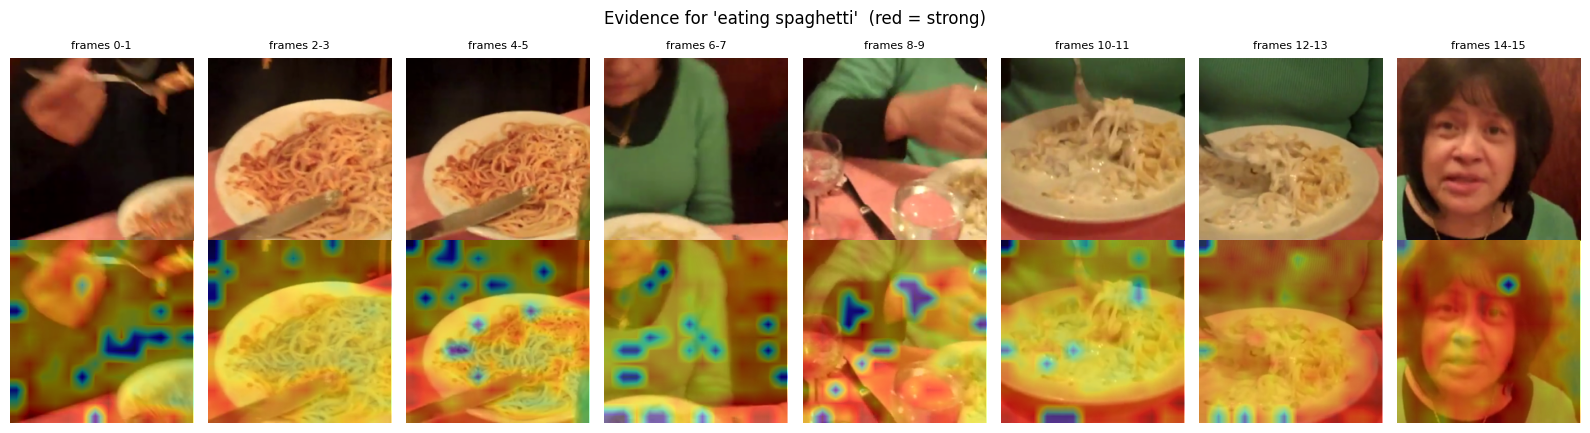

In [ ]:
T, H = 16 // cfg.tubelet_size, 224 // cfg.patch_size        # 8 time steps, 14 x 14 grid
pred = out.logits.argmax(-1).item()
with torch.no_grad():
    tokens = out.hidden_states[-1][0]                          # (1568, 768)
    cam = model.classifier(model.fc_norm(tokens))[:, pred]     # one class score per token
cam = cam.reshape(T, H, H).cpu().numpy()
cam = (cam - cam.min()) / (cam.max() - cam.min())

# Undo the processor's normalization to show exactly what the model sees
mean = torch.tensor(processor.image_mean).view(1, 3, 1, 1)
std = torch.tensor(processor.image_std).view(1, 3, 1, 1)
crops = (inputs.pixel_values[0].cpu() * std + mean).clamp(0, 1).permute(0, 2, 3, 1).numpy()

fig, ax = plt.subplots(2, T, figsize=(16, 4.4))
for t in range(T):
    ax[0, t].imshow(crops[2 * t]); ax[0, t].set_title(f"frames {2*t}-{2*t+1}", fontsize=8)
    ax[1, t].imshow(crops[2 * t])
    ax[1, t].imshow(cam[t], cmap="jet", alpha=0.45, extent=(0, 224, 224, 0), interpolation="bilinear")
    ax[0, t].axis("off"); ax[1, t].axis("off")
fig.suptitle(f"Evidence for '{model.config.id2label[pred]}'  (red = strong)")
plt.tight_layout(); plt.show()

## 4. Does the model actually use time?

If the model only recognized objects in single frames, the order of the frames would not matter. We test this by shuffling and by reversing the frames. The objects stay the same; only the motion changes.

In [ ]:
rng = np.random.default_rng(0)
tests = {"original": video,
         "reversed": video[::-1],
         "shuffled": [video[i] for i in rng.permutation(16)],
         "one frame x16 (no motion)": [video[8]] * 16}

for name, frames in tests.items():
    label, p = top5(frames)[0]
    print(f"{name:28s} -> {label} ({p:.1%})")

original                     -> eating spaghetti (79.2%)
reversed                     -> eating spaghetti (78.7%)
shuffled                     -> eating spaghetti (70.9%)
one frame x16 (no motion)    -> eating burger (19.6%)


**What to notice:** for this clip, reversing or shuffling the frames changes the prediction only a little, but removing all motion (one frame repeated) changes it a lot. "Eating spaghetti" is mostly recognizable from *appearance*: a plate of spaghetti and a fork. Many Kinetics actions are like this (a known "scene bias"). Actions defined by *direction* are different: "opening" vs. "closing" a door, or "putting something down" vs. "picking it up". Models trained on datasets such as Something-Something v2, where only the motion tells the classes apart, are much more sensitive to frame order.

## 5. Zero-shot video classification with X-CLIP

VideoMAE can only choose among its 400 training labels. **X-CLIP** (Microsoft) learns a shared space for videos and text, like CLIP does for images. You can describe *any* set of categories in plain text, and it picks the best match, with no training.

In [ ]:
from transformers import XCLIPProcessor, XCLIPModel

xclip_ckpt = "microsoft/xclip-base-patch32"          # uses 8 frames
xproc = XCLIPProcessor.from_pretrained(xclip_ckpt)
xclip = XCLIPModel.from_pretrained(xclip_ckpt).eval().to(device)

def zero_shot(frames, texts):
    inputs = xproc(text=texts, videos=[frames], return_tensors="pt", padding=True).to(device)
    with torch.no_grad():
        probs = xclip(**inputs).logits_per_video.softmax(-1)[0]
    for t, p in sorted(zip(texts, probs.tolist()), key=lambda z: -z[1]):
        print(f"{p:6.1%}  {t}")

texts = ["a person eating pasta", "a person cooking in a kitchen", "a person playing guitar",
         "a dog running in a park", "people dancing"]
zero_shot(load_frames(path, 8), texts)

Loading weights:   0%|          | 0/591 [00:00<?, ?it/s]

 99.5%  a person eating pasta
  0.2%  a person cooking in a kitchen
  0.1%  a person playing guitar
  0.1%  people dancing
  0.0%  a dog running in a park


Try: edit `texts` above. Make the choices harder ("eating spaghetti with a fork" vs. "eating spaghetti with chopsticks") and see where the model breaks.

## 6. Demo: a new video (basketball dunk)

Now we run everything on a different clip: a 5-second basketball dunk from the **UCF101** action dataset (320 × 240 pixels, 125 frames). Neither model was trained on this particular clip.

v_BasketballDunk_g14_c06.avi: reconstructing file:   0%|          |  0.00B /  546kB            

v_BasketballDunk_g14_c06.avi: downloading bytes:           |  0.00B            

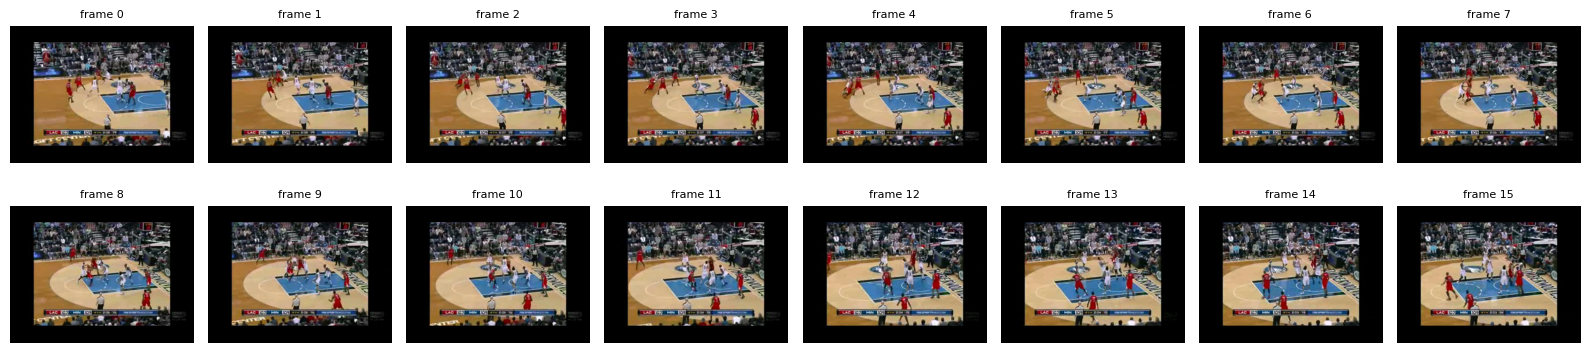

VideoMAE (fixed list of 400 Kinetics actions):
   55.0%  dunking basketball
   10.7%  playing basketball
    3.5%  dribbling basketball
    1.6%  shooting basketball
    0.2%  squat


In [ ]:
demo_path = hf_hub_download(repo_id="sayakpaul/ucf101-subset",
                            filename="v_BasketballDunk_g14_c06.avi", repo_type="dataset")
demo = load_frames(demo_path, 16)

fig, ax = plt.subplots(2, 8, figsize=(16, 4))
for i, a in enumerate(ax.flat):
    a.imshow(demo[i]); a.set_title(f"frame {i}", fontsize=8); a.axis("off")
plt.tight_layout(); plt.show()

print("VideoMAE (fixed list of 400 Kinetics actions):")
for label, p in top5(demo):
    print(f"  {p:6.1%}  {label}")

VideoMAE's top guesses should all be basketball actions: the model separates *dunking* from *playing* or *dribbling*, which differ mostly in motion.

Next, X-CLIP with two sets of text. The **easy** set contains very different activities; the **hard** set contains only basketball actions.

In [ ]:
demo8 = load_frames(demo_path, 8)

print("X-CLIP, easy choices:")
zero_shot(demo8, ["a person playing basketball", "a person shooting a bow and arrow",
                  "a baby crawling on the floor", "a person riding a bicycle", "a person eating pasta"])

print("\nX-CLIP, hard choices (all basketball):")
zero_shot(demo8, ["dunking basketball", "dribbling basketball",
                  "shooting basketball", "passing basketball"])

X-CLIP, easy choices:
 97.8%  a person playing basketball
  1.0%  a person shooting a bow and arrow
  0.7%  a person riding a bicycle
  0.3%  a baby crawling on the floor
  0.2%  a person eating pasta

X-CLIP, hard choices (all basketball):
 69.9%  dunking basketball
 15.6%  shooting basketball
  8.4%  dribbling basketball
  6.1%  passing basketball


**What to notice:** with easy choices, X-CLIP is almost certain. With fine-grained choices it still picks *dunking*, but with much lower confidence, because the scene (court, ball, players) is the same for all four; only the motion differs. This is the same appearance-versus-motion theme as in section 4.

## 7. Try your own video

Upload a short clip (a few seconds is enough) and run both models on it.

In [ ]:
from google.colab import files
uploaded = files.upload()
my_path = next(iter(uploaded))

for label, p in top5(load_frames(my_path, 16)):
    print(f"VideoMAE  {p:6.1%}  {label}")
print()
zero_shot(load_frames(my_path, 8), ["describe", "your", "own", "categories", "here"])

StopIteration: 

## Key ideas

| Concept | Meaning |
|---|---|
| Tubelet | A 3D patch (e.g., 2 frames × 16 × 16 pixels) that becomes one token |
| Spatiotemporal attention | Every token attends to all others, across space and time; cost grows with tokens² |
| Masked pretraining (VideoMAE) | Hide ~90% of tubelets and reconstruct them; videos are redundant, so this works |
| Divided attention (TimeSformer) | A cheaper alternative: attend over time, then over space, separately |
| Video–text models (X-CLIP) | Put videos and text in one embedding space; enables zero-shot classification and retrieval |

## Next steps

- **Fine-tune on your own labels:** the Hugging Face "Video classification" task guide fine-tunes VideoMAE on UCF101.
- **Papers:** ViViT (Arnab et al., 2021), TimeSformer (Bertasius et al., 2021), VideoMAE (Tong et al., 2022), X-CLIP (Ni et al., 2022).
- **Video + language models** that answer questions about a video: Video-LLaVA, Qwen2.5-VL, LLaVA-OneVision.